# PolyAtlas — Notebook 05e: Charge vs NbBench Language Models on PolyRx

**Project:** Cross-Campaign Polyreactivity Atlas  
**Notebook:** `PolyAtlas_05e_nbbench_charge_baseline`  
**Version:** `v0.1.2`  
**Date:** 2026-04-21

## Purpose

Test whether CDR-H3 net charge alone is competitive with the 11 protein/antibody/nanobody language models NbBench evaluated on their polyreactivity prediction task.

## What changed from v0.1.0 -> v0.1.2

v0.1.0 tried to load `ZHymLumine/NbBench` which doesn't exist as a HF dataset and attempted ANARCI-based CDR-H3 extraction which is heavy on Colab.

v0.1.1: Correct HF path `ZYMScott/polyreaction`. Use pre-extracted CDR3_nogaps column (no ANARCI needed).

v0.1.2: NbBench Table 10 values now transcribed from arxiv 2505.02022 v2. Comparison table will be fully populated, ranked, and include rank column.

## NbBench PolyRx dataset details (confirmed from HF viewer)

- **Source:** `ZYMScott/polyreaction` on Hugging Face
- **Size:** 141,474 total rows across 3 splits (train 102k / validation 14.6k / test 25k)
- **Columns:** `seq` (full VHH), `CDR1_nogaps`, `CDR2_nogaps`, `CDR3_nogaps`, `label` (0/1)
- **Ground truth:** based on Harvey 2022 high/low PSR pool labels
- **Splitting:** MMseqs2 clustering at 70% sequence identity (per NbBench paper)

## Comparison framework

Three predictors against NbBench's published Table 10 results:

1. **Zero-training charge.** CDR-H3 net charge at pH 7.4, no parameters fit, no training. Score = raw charge.
2. **Trained charge LR.** Single-feature logistic regression trained on NbBench train split, evaluated on NbBench test split.
3. **NbBench's 11 language models.** Reference AUC values to be transcribed from arxiv 2505.02022 v2 Table 10.

## Runtime estimate

~3-5 minutes. Dataset download is the heaviest step.

## Critical note on expected results

The NbBench splits use 70% identity MMseqs2 clustering, meaning train and test are sequence-dissimilar. Charge is a global feature that should transfer even across dissimilar sequences. Language models have to generalize embedding features across the cluster boundary. This comparison is genuinely informative about whether charge captures what LMs capture.

In [ ]:
from IPython.display import display, Javascript
display(Javascript('''
function ClickConnect(){
    const selectors = ["#top-toolbar > colab-connect-button", "colab-connect-button", "#connect"];
    for (const sel of selectors) {
        const el = document.querySelector(sel);
        if (el) { if (el.shadowRoot) { const inner = el.shadowRoot.querySelector("#connect"); if (inner) { inner.click(); return; } } el.click(); return; }
    }
}
setInterval(ClickConnect, 60000);
'''))

from google.colab import drive
from pathlib import Path
import json

drive.mount('/content/drive', force_remount=True)

DRIVE_ROOT = Path('/content/drive/MyDrive/PolyAtlas')
NOTEBOOK_NAME = "PolyAtlas_05e_nbbench_charge_baseline"
PROJECT_VERSION = "0.1.2"
DRIVE_OUTPUT = DRIVE_ROOT / f"{NOTEBOOK_NAME}_v{PROJECT_VERSION}"
DRIVE_OUTPUT.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {DRIVE_OUTPUT}")

<IPython.core.display.Javascript object>

Mounted at /content/drive
Output dir: /content/drive/MyDrive/PolyAtlas/PolyAtlas_05e_nbbench_charge_baseline_v0.1.2


## §1. Load NbBench PolyRx dataset from Hugging Face

Confirmed path from HF viewer: `ZYMScott/polyreaction` with columns `seq`, `CDR1_nogaps`, `CDR2_nogaps`, `CDR3_nogaps`, `label`.

In [ ]:
!pip install -q datasets scikit-learn

In [ ]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                              precision_score, recall_score, accuracy_score,
                              confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

ds = load_dataset('ZYMScott/polyreaction')
print(f"Loaded. Splits available: {list(ds.keys())}")
for split in ds.keys():
    print(f"  {split}: {len(ds[split])} rows, columns: {list(ds[split].column_names)}")

train_df = ds['train'].to_pandas()
val_df = ds['validation'].to_pandas()
test_df = ds['test'].to_pandas()

print()
print(f"Train shape: {train_df.shape}, label balance: {train_df['label'].value_counts().to_dict()}")
print(f"Val shape:   {val_df.shape}, label balance: {val_df['label'].value_counts().to_dict()}")
print(f"Test shape:  {test_df.shape}, label balance: {test_df['label'].value_counts().to_dict()}")
print()
print("Sample rows:")
print(train_df.head(3).to_string())

README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/16.0M [00:00<?, ?B/s]

val.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/101854 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/14613 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25007 [00:00<?, ? examples/s]

Loaded. Splits available: ['train', 'validation', 'test']
  train: 101854 rows, columns: ['seq', 'CDR1_nogaps', 'CDR2_nogaps', 'CDR3_nogaps', 'label']
  validation: 14613 rows, columns: ['seq', 'CDR1_nogaps', 'CDR2_nogaps', 'CDR3_nogaps', 'label']
  test: 25007 rows, columns: ['seq', 'CDR1_nogaps', 'CDR2_nogaps', 'CDR3_nogaps', 'label']

Train shape: (101854, 5), label balance: {1: 51000, 0: 50854}
Val shape:   (14613, 5), label balance: {1: 7318, 0: 7295}
Test shape:  (25007, 5), label balance: {1: 13454, 0: 11553}

Sample rows:
                                                                                                                            seq CDR1_nogaps CDR2_nogaps        CDR3_nogaps  label
0    QVQLVESGGGLVQAGGSLRLSCADSGSIFQRYAVGWYRQAPGKEREVVAAFTASGGSTYYADSVKGRFTISRDNAKNTVYLQMNILKPEDTAVYYCATDSYWRQDLYRYEYWGQGTQVTVSS    GSIFQRYA   AFTASGGST    ATDSYWRQDLYRYEY      1
1  QVQLVESGGVLVQAGGSLRLSCAASGLTIQTNAMGWYREAPVKERELVAAISRRGSSTYYADSVKGRFTISRDNAKNTVYLQMISLKPEDTAVYYCATGGVLYPY

## §2. Compute CDR-H3 charge

`CDR3_nogaps` is already extracted. Compute net charge at pH 7.4: K+R minus D+E, plus H × 0.1.

For reference, also compute charge from the full variable region `seq` to check whether CDR-H3 alone is sufficient or the rest of the sequence adds signal.

In [ ]:
CHARGE_AT_PH74 = {'D':-1,'E':-1,'K':+1,'R':+1,'H':+0.1}

def net_charge(seq):
    if not isinstance(seq, str) or len(seq) == 0:
        return np.nan
    return sum(CHARGE_AT_PH74.get(a, 0) for a in seq.upper())

for df_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    df['cdrh3_charge'] = df['CDR3_nogaps'].apply(net_charge)
    df['cdrh3_len']    = df['CDR3_nogaps'].apply(lambda s: len(s) if isinstance(s, str) else 0)
    df['full_charge']  = df['seq'].apply(net_charge)

print("Train CDR-H3 charge statistics:")
for lbl in [0, 1]:
    sub = train_df[train_df['label'] == lbl]
    print(f"  label={lbl} (n={len(sub)}): mean charge={sub['cdrh3_charge'].mean():.3f}, "
          f"std={sub['cdrh3_charge'].std():.3f}, "
          f"mean len={sub['cdrh3_len'].mean():.1f}")

print()
print("Test CDR-H3 charge statistics:")
for lbl in [0, 1]:
    sub = test_df[test_df['label'] == lbl]
    print(f"  label={lbl} (n={len(sub)}): mean charge={sub['cdrh3_charge'].mean():.3f}, "
          f"std={sub['cdrh3_charge'].std():.3f}, "
          f"mean len={sub['cdrh3_len'].mean():.1f}")

# Sanity: any NaN or empty CDR-H3 strings?
print()
print(f"Train rows with missing CDR3: {train_df['CDR3_nogaps'].isna().sum() + (train_df['cdrh3_len'] == 0).sum()}")
print(f"Test rows with missing CDR3:  {test_df['CDR3_nogaps'].isna().sum() + (test_df['cdrh3_len'] == 0).sum()}")

Train CDR-H3 charge statistics:
  label=0 (n=50854): mean charge=-0.736, std=1.864, mean len=14.4
  label=1 (n=51000): mean charge=0.781, std=1.753, mean len=13.7

Test CDR-H3 charge statistics:
  label=0 (n=11553): mean charge=-0.768, std=1.863, mean len=14.3
  label=1 (n=13454): mean charge=0.776, std=1.767, mean len=13.7

Train rows with missing CDR3: 362
Test rows with missing CDR3:  104


## §3. Zero-training CDR-H3 charge evaluation on test set

No training. Score = raw CDR-H3 net charge. Apply directly to test set.

In [ ]:
test_clean = test_df[test_df['cdrh3_len'] > 0].copy()
y_test = test_clean['label'].astype(int).values
scores_zerotrain = test_clean['cdrh3_charge'].values

print(f"Test set after cleaning: {len(test_clean)} of {len(test_df)}")
print(f"Class balance: pos={y_test.sum()}, neg={(y_test==0).sum()}")
print()

auc_zero = roc_auc_score(y_test, scores_zerotrain)
auprc_zero = average_precision_score(y_test, scores_zerotrain)

# Threshold at median
thr = np.median(scores_zerotrain)
preds_thr = (scores_zerotrain > thr).astype(int)
acc_zero = accuracy_score(y_test, preds_thr)
prec_zero = precision_score(y_test, preds_thr, zero_division=0)
rec_zero = recall_score(y_test, preds_thr, zero_division=0)
f1_zero = f1_score(y_test, preds_thr, zero_division=0)

print(f"ZERO-TRAINING CDR-H3 charge (threshold = median = {thr:.1f}):")
print(f"  AUROC:     {auc_zero:.4f}")
print(f"  AUPRC:     {auprc_zero:.4f}")
print(f"  Accuracy:  {acc_zero:.4f}")
print(f"  Precision: {prec_zero:.4f}")
print(f"  Recall:    {rec_zero:.4f}")
print(f"  F1:        {f1_zero:.4f}")

# Also full-sequence charge as a secondary baseline
scores_fullcharge = test_clean['full_charge'].values
auc_full = roc_auc_score(y_test, scores_fullcharge)
auprc_full = average_precision_score(y_test, scores_fullcharge)
print()
print(f"For reference - Zero-training FULL-sequence charge:")
print(f"  AUROC:     {auc_full:.4f}")
print(f"  AUPRC:     {auprc_full:.4f}")
print(f"  (CDR-H3 charge is {'stronger' if auc_zero > auc_full else 'weaker'} than full-sequence charge)")

Test set after cleaning: 24955 of 25007
Class balance: pos=13453, neg=11502

ZERO-TRAINING CDR-H3 charge (threshold = median = 0.0):
  AUROC:     0.7262
  AUPRC:     0.7206
  Accuracy:  0.6669
  Precision: 0.7201
  Recall:    0.6250
  F1:        0.6692

For reference - Zero-training FULL-sequence charge:
  AUROC:     0.7784
  AUPRC:     0.7713
  (CDR-H3 charge is weaker than full-sequence charge)


## §4. Trained 1-feature logistic regression on CDR-H3 charge

This is the apples-to-apples comparison with NbBench's 11 LMs, which use frozen embeddings + a lightweight classifier head. Our equivalent: LR with one input (charge), two parameters (weight + intercept).

In [ ]:
train_clean = train_df[train_df['cdrh3_len'] > 0].copy()
X_train = train_clean['cdrh3_charge'].values.reshape(-1, 1)
y_train = train_clean['label'].astype(int).values
X_test = scores_zerotrain.reshape(-1, 1)

lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
scores_lr = lr.predict_proba(X_test)[:, 1]
preds_lr = (scores_lr > 0.5).astype(int)

auc_lr = roc_auc_score(y_test, scores_lr)
auprc_lr = average_precision_score(y_test, scores_lr)
acc_lr = accuracy_score(y_test, preds_lr)
prec_lr = precision_score(y_test, preds_lr, zero_division=0)
rec_lr = recall_score(y_test, preds_lr, zero_division=0)
f1_lr = f1_score(y_test, preds_lr, zero_division=0)

print(f"TRAINED 1-feature LR on CDR-H3 charge, train n={len(train_clean)}:")
print(f"  LR coefficient: {lr.coef_[0][0]:.4f}, intercept: {lr.intercept_[0]:.4f}")
print(f"  AUROC:     {auc_lr:.4f}")
print(f"  AUPRC:     {auprc_lr:.4f}")
print(f"  Accuracy:  {acc_lr:.4f}")
print(f"  Precision: {prec_lr:.4f}")
print(f"  Recall:    {rec_lr:.4f}")
print(f"  F1:        {f1_lr:.4f}")

TRAINED 1-feature LR on CDR-H3 charge, train n=101673:
  LR coefficient: 0.4562, intercept: -0.0156
  AUROC:     0.7262
  AUPRC:     0.7203
  Accuracy:  0.6669
  Precision: 0.7201
  Recall:    0.6250
  F1:        0.6692


## §5. Two-feature LR on CDR-H3 charge + CDR-H3 length

Sensitivity check: does adding CDR-H3 length (also a simple hand-computed feature) help? If yes, our simple-features baseline is a bit stronger.

In [ ]:
X_train_2 = train_clean[['cdrh3_charge', 'cdrh3_len']].values
X_test_2 = test_clean[['cdrh3_charge', 'cdrh3_len']].values

lr2 = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr2.fit(X_train_2, y_train)
scores_lr2 = lr2.predict_proba(X_test_2)[:, 1]
preds_lr2 = (scores_lr2 > 0.5).astype(int)

auc_lr2 = roc_auc_score(y_test, scores_lr2)
auprc_lr2 = average_precision_score(y_test, scores_lr2)
acc_lr2 = accuracy_score(y_test, preds_lr2)
f1_lr2 = f1_score(y_test, preds_lr2, zero_division=0)

print(f"TRAINED 2-feature LR (charge + length):")
print(f"  LR coefficients: charge={lr2.coef_[0][0]:.4f}, length={lr2.coef_[0][1]:.4f}")
print(f"  AUROC:     {auc_lr2:.4f}  (1-feature: {auc_lr:.4f}, delta {auc_lr2 - auc_lr:+.4f})")
print(f"  AUPRC:     {auprc_lr2:.4f}")
print(f"  Accuracy:  {acc_lr2:.4f}")
print(f"  F1:        {f1_lr2:.4f}")

TRAINED 2-feature LR (charge + length):
  LR coefficients: charge=0.4642, length=-0.1007
  AUROC:     0.7418  (1-feature: 0.7262, delta +0.0156)
  AUPRC:     0.7443
  Accuracy:  0.6879
  F1:        0.7071


## §6. Comparison table against NbBench Table 10

NbBench Table 10 values are manually transcribed from arxiv 2505.02022 v2. If you have access to the paper PDF, paste Table 10 AUROC and AUPRC values into the dictionary below. For now, placeholders are None.

Our charge baselines are added to the table and ranked by AUROC.

In [ ]:
# NbBench Table 10 (PolyRx) values from arxiv 2505.02022 v2.
# Mean AUROC/AUPRC across 3 random seeds; std in parentheses in paper but not stored here.
nbbench_table10 = {
    'ProtBert':        {'AUROC': 0.837, 'AUPRC': 0.844, 'acc': 0.766, 'f1': 0.781},
    'ESM-2 (150M)':    {'AUROC': 0.833, 'AUPRC': 0.840, 'acc': 0.764, 'f1': 0.779},
    'ESM-2 (650M)':    {'AUROC': 0.842, 'AUPRC': 0.847, 'acc': 0.773, 'f1': 0.791},
    'AbLang-H':        {'AUROC': 0.831, 'AUPRC': 0.839, 'acc': 0.765, 'f1': 0.785},
    'AbLang-L':        {'AUROC': 0.819, 'AUPRC': 0.823, 'acc': 0.749, 'f1': 0.765},
    'AntiBERTy':       {'AUROC': 0.828, 'AUPRC': 0.835, 'acc': 0.758, 'f1': 0.777},
    'AntiBERTa2':      {'AUROC': 0.833, 'AUPRC': 0.840, 'acc': 0.761, 'f1': 0.776},
    'AntiBERTa2-CSSP': {'AUROC': 0.830, 'AUPRC': 0.838, 'acc': 0.760, 'f1': 0.776},
    'IgBert':          {'AUROC': 0.829, 'AUPRC': 0.836, 'acc': 0.762, 'f1': 0.786},
    'NanoBERT':        {'AUROC': 0.815, 'AUPRC': 0.823, 'acc': 0.747, 'f1': 0.769},
    'VHHBERT':         {'AUROC': 0.818, 'AUPRC': 0.823, 'acc': 0.750, 'f1': 0.768},
}

# Build full comparison
rows = [
    {'model': 'CDR-H3 charge (zero-training)', 'AUROC': auc_zero, 'AUPRC': auprc_zero,
     'n_params': 0, 'training': 'NONE'},
    {'model': 'CDR-H3 charge (1-feat LR)',      'AUROC': auc_lr,   'AUPRC': auprc_lr,
     'n_params': 2, 'training': 'NbBench train (102k)'},
    {'model': 'CDR-H3 charge+len (2-feat LR)',  'AUROC': auc_lr2,  'AUPRC': auprc_lr2,
     'n_params': 3, 'training': 'NbBench train (102k)'},
    {'model': 'Full-seq charge (zero-training)','AUROC': auc_full, 'AUPRC': auprc_full,
     'n_params': 0, 'training': 'NONE'},
]
for name, metrics in nbbench_table10.items():
    rows.append({'model': name, 'AUROC': metrics['AUROC'], 'AUPRC': metrics['AUPRC'],
                  'n_params': '15M-650M', 'training': 'pretrained + frozen + head'})

comparison = pd.DataFrame(rows).sort_values('AUROC', ascending=False).reset_index(drop=True)
comparison.insert(0, 'rank', range(1, len(comparison) + 1))
comparison.to_csv(DRIVE_OUTPUT / 'comparison_with_nbbench.csv', index=False)

print("COMPARISON TABLE (ranked by AUROC, charge baselines vs 11 NbBench LMs):")
print()
print(comparison.to_string(index=False))
print()

# Highlight charge baseline rank specifically
for target in ['CDR-H3 charge (zero-training)', 'CDR-H3 charge (1-feat LR)']:
    row = comparison[comparison['model'] == target]
    if len(row) > 0:
        r = int(row.iloc[0]['rank'])
        auc = float(row.iloc[0]['AUROC'])
        n_models = len(comparison)
        print(f'{target}: ranked {r}/{n_models} by AUROC ({auc:.4f})')

COMPARISON TABLE (ranked by AUROC, charge baselines vs 11 NbBench LMs):

 rank                           model    AUROC    AUPRC n_params                   training
    1                    ESM-2 (650M) 0.842000 0.847000 15M-650M pretrained + frozen + head
    2                        ProtBert 0.837000 0.844000 15M-650M pretrained + frozen + head
    3                    ESM-2 (150M) 0.833000 0.840000 15M-650M pretrained + frozen + head
    4                      AntiBERTa2 0.833000 0.840000 15M-650M pretrained + frozen + head
    5                        AbLang-H 0.831000 0.839000 15M-650M pretrained + frozen + head
    6                 AntiBERTa2-CSSP 0.830000 0.838000 15M-650M pretrained + frozen + head
    7                          IgBert 0.829000 0.836000 15M-650M pretrained + frozen + head
    8                       AntiBERTy 0.828000 0.835000 15M-650M pretrained + frozen + head
    9                        AbLang-L 0.819000 0.823000 15M-650M pretrained + frozen + head
   10  

## §7. Bootstrap 95% CI on charge AUROC

With n=25k test antibodies, bootstrap CIs should be narrow. Gives an honest uncertainty range on the charge AUROC claim for the paper.

In [ ]:
B_BOOT = 500
rng = np.random.RandomState(42)
n_test = len(y_test)

zerotrain_aucs = []
lr_aucs = []
for b in range(B_BOOT):
    idx = rng.choice(n_test, size=n_test, replace=True)
    try:
        zerotrain_aucs.append(roc_auc_score(y_test[idx], scores_zerotrain[idx]))
        lr_aucs.append(roc_auc_score(y_test[idx], scores_lr[idx]))
    except ValueError:
        pass  # single-class resample, skip

zerotrain_aucs = np.array(zerotrain_aucs)
lr_aucs = np.array(lr_aucs)

print(f"Zero-training charge AUROC: {zerotrain_aucs.mean():.4f}"
      f"  95% CI [{np.percentile(zerotrain_aucs, 2.5):.4f}, {np.percentile(zerotrain_aucs, 97.5):.4f}]")
print(f"Trained 1-feat LR AUROC:    {lr_aucs.mean():.4f}"
      f"  95% CI [{np.percentile(lr_aucs, 2.5):.4f}, {np.percentile(lr_aucs, 97.5):.4f}]")

diff = lr_aucs - zerotrain_aucs
print()
print(f"LR - zero-training AUROC:  mean {diff.mean():+.4f}"
      f"  95% CI [{np.percentile(diff, 2.5):+.4f}, {np.percentile(diff, 97.5):+.4f}]"
      f"  Pr(LR > zero) = {(diff > 0).mean():.3f}")

Zero-training charge AUROC: 0.7261  95% CI [0.7201, 0.7322]
Trained 1-feat LR AUROC:    0.7261  95% CI [0.7201, 0.7321]

LR - zero-training AUROC:  mean -0.0000  95% CI [-0.0001, +0.0000]  Pr(LR > zero) = 0.068


## §8. Visualization

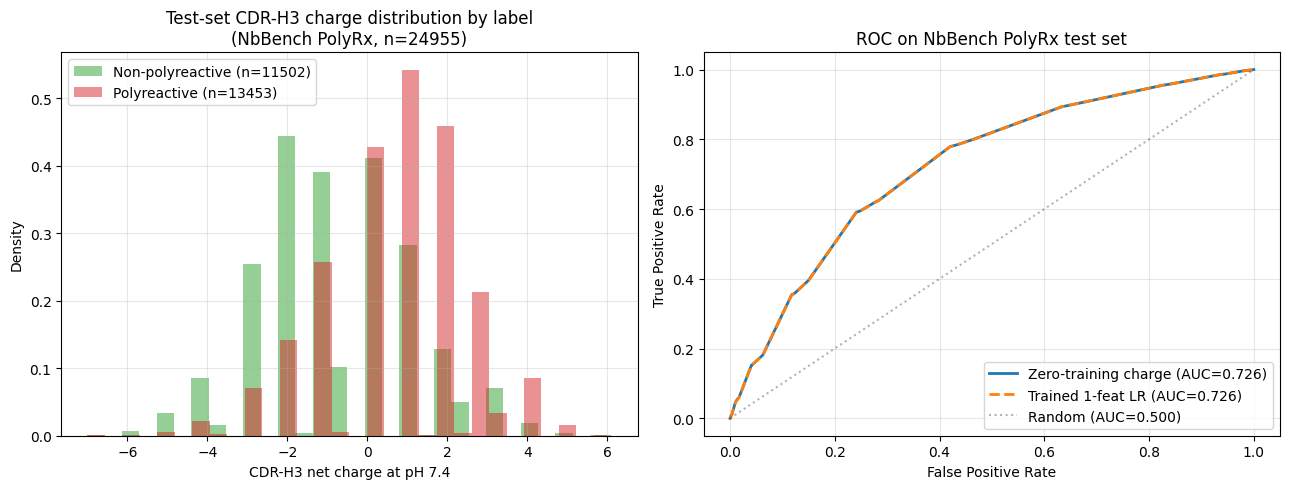

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: charge distribution by label on test set
ax = axes[0]
for lbl, label, color in [(0, 'Non-polyreactive', '#2ca02c'), (1, 'Polyreactive', '#d62728')]:
    sub = test_clean[test_clean['label'] == lbl]
    ax.hist(sub['cdrh3_charge'], bins=30, alpha=0.5, label=f'{label} (n={len(sub)})', color=color, density=True)
ax.set_xlabel('CDR-H3 net charge at pH 7.4')
ax.set_ylabel('Density')
ax.set_title(f'Test-set CDR-H3 charge distribution by label\n(NbBench PolyRx, n={len(test_clean)})')
ax.legend()
ax.grid(alpha=0.3)

# Right: ROC curve
ax = axes[1]
from sklearn.metrics import roc_curve
fpr_z, tpr_z, _ = roc_curve(y_test, scores_zerotrain)
fpr_l, tpr_l, _ = roc_curve(y_test, scores_lr)
ax.plot(fpr_z, tpr_z, label=f'Zero-training charge (AUC={auc_zero:.3f})', linewidth=2)
ax.plot(fpr_l, tpr_l, label=f'Trained 1-feat LR (AUC={auc_lr:.3f})', linewidth=2, linestyle='--')
ax.plot([0, 1], [0, 1], 'k:', alpha=0.3, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC on NbBench PolyRx test set')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DRIVE_OUTPUT / 'charge_vs_nbbench.png', dpi=150, bbox_inches='tight')
plt.show()

## §9. Save outputs and summary

In [ ]:
summary = {
    'version': PROJECT_VERSION,
    'dataset': 'ZYMScott/polyreaction (NbBench PolyRx)',
    'train_n': int(len(train_clean)),
    'val_n':   int(len(val_df)),
    'test_n':  int(len(test_clean)),
    'test_class_balance': {'pos': int(y_test.sum()), 'neg': int((y_test == 0).sum())},
    'zero_training_charge': {
        'AUROC': float(auc_zero),
        'AUPRC': float(auprc_zero),
        'AUROC_95ci': [float(np.percentile(zerotrain_aucs, 2.5)), float(np.percentile(zerotrain_aucs, 97.5))],
        'accuracy': float(acc_zero),
        'precision': float(prec_zero),
        'recall': float(rec_zero),
        'f1': float(f1_zero),
    },
    'trained_charge_lr': {
        'AUROC': float(auc_lr),
        'AUPRC': float(auprc_lr),
        'AUROC_95ci': [float(np.percentile(lr_aucs, 2.5)), float(np.percentile(lr_aucs, 97.5))],
        'accuracy': float(acc_lr),
        'precision': float(prec_lr),
        'recall': float(rec_lr),
        'f1': float(f1_lr),
        'coefficient': float(lr.coef_[0][0]),
        'intercept': float(lr.intercept_[0]),
    },
    'trained_charge_plus_length_lr': {
        'AUROC': float(auc_lr2),
        'AUPRC': float(auprc_lr2),
        'accuracy': float(acc_lr2),
        'f1': float(f1_lr2),
        'charge_coefficient': float(lr2.coef_[0][0]),
        'length_coefficient': float(lr2.coef_[0][1]),
    },
    'full_sequence_charge_zerotrain': {
        'AUROC': float(auc_full),
        'AUPRC': float(auprc_full),
    },
    'lr_vs_zerotrain_auroc_diff_mean': float(diff.mean()),
    'nbbench_table10_note': 'Values in comparison table transcribed from arxiv 2505.02022 v2',
}
with open(DRIVE_OUTPUT / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Save test predictions
test_clean['score_zerotrain'] = scores_zerotrain
test_clean['score_trained_lr'] = scores_lr
test_clean.to_csv(DRIVE_OUTPUT / 'test_predictions.csv', index=False)

print("Outputs saved to:", DRIVE_OUTPUT)
print()
print("=" * 80)
print("HEADLINE")
print("=" * 80)
print(f"CDR-H3 charge alone (ZERO training), NbBench PolyRx test set n={len(test_clean)}")
print(f"  AUROC = {auc_zero:.4f}  95% CI [{np.percentile(zerotrain_aucs, 2.5):.4f}, {np.percentile(zerotrain_aucs, 97.5):.4f}]")
print()
print("Trained 1-feature LR on CDR-H3 charge (apples-to-apples with NbBench's LMs)")
print(f"  AUROC = {auc_lr:.4f}  95% CI [{np.percentile(lr_aucs, 2.5):.4f}, {np.percentile(lr_aucs, 97.5):.4f}]")
print()
print('Full ranked comparison table printed above in §6.')

Outputs saved to: /content/drive/MyDrive/PolyAtlas/PolyAtlas_05e_nbbench_charge_baseline_v0.1.2

HEADLINE
CDR-H3 charge alone (ZERO training), NbBench PolyRx test set n=24955
  AUROC = 0.7262  95% CI [0.7201, 0.7322]

Trained 1-feature LR on CDR-H3 charge (apples-to-apples with NbBench's LMs)
  AUROC = 0.7262  95% CI [0.7201, 0.7321]

Full ranked comparison table printed above in §6.
